<!-- @format -->

# Adult Income Predition - Deep Learning Pipeline

Xây dựng pipeline Deep Learning hoàn chỉnh cho bài toán phân loại thu nhập trên tập dữ liệu Adult Census.

**Pipeline gồm các bước:**

1. Tổng quan dữ liệu
2. Tiền xử lí dữ liệu
4. Huấn luyện mô hình
5. Đánh giá & so sánh tổng hợp


<!-- @format -->

## 1. Tổng quan dữ liệu

Phần này tóm tắt nhanh đặc trưng dữ liệu, phân phối target và các đặc trưng quan trọng nhất, giúp định hướng cho pipeline deep learning.


In [1]:
# Import thư viện và load dữ liệu
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import modules.eda as eda

import modules.deep_learning as dl

url = "https://raw.githubusercontent.com/Hanne2202/ml-group10-data/main/adult.csv"
df = eda.load_data(url)


Dataset shape: (48842, 15)
   age  workclass  fnlwgt     education  educational-num      marital-status  \
0   25    Private  226802          11th                7       Never-married   
1   38    Private   89814       HS-grad                9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm               12  Married-civ-spouse   
3   44    Private  160323  Some-college               10  Married-civ-spouse   
4   18          ?  103497  Some-college               10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                  ?    Own-child  White  Female             0             0   

   hours-pe

In [2]:
# Tổng quan nhanh dữ liệu
eda.dataset_overview(df)
num_cols, cat_cols = eda.get_column_types(df)


=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

=== Numerical Summary ===
                age       

In [3]:
# Kiểm tra missing value và giá trị bất thường
eda.check_missing_values(df)
eda.inspect_categorical_values(df, cat_cols)


=== Missing values (NaN) ===
age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

=== '?' count per column ===
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

Column: workclass  |  unique: 9
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay    

<!-- @format -->

**Nhận xét:** Một số cột phân loại có giá trị '?' thay cho missing value. Cần chuẩn hóa về NaN trước khi xử lý tiếp.


Unique values: ['<=50K' '>50K']

Class counts:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Class percentages (%):
income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


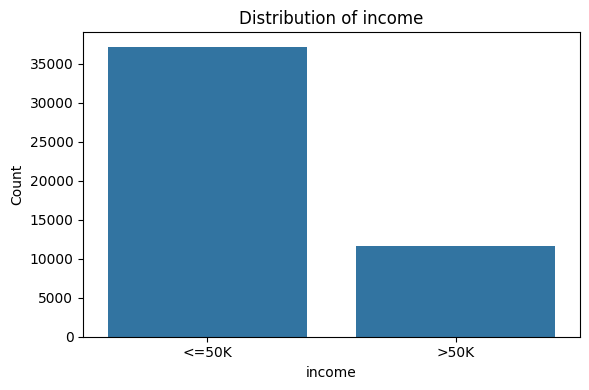

In [4]:
# Phân phối biến mục tiêu (income)
eda.plot_target_distribution(df, target_col='income')

<!-- @format -->

**Nhận xét:** Dữ liệu có mất cân bằng nhẹ giữa hai lớp thu nhập (>50K và <=50K), cần lưu ý khi đánh giá mô hình. Nhóm dự định sẽ sử dụng phương pháp SMOTE để cân bằng lại số lượng của 2 lớp này giúp tránh overfitting đối với người có income >50k.


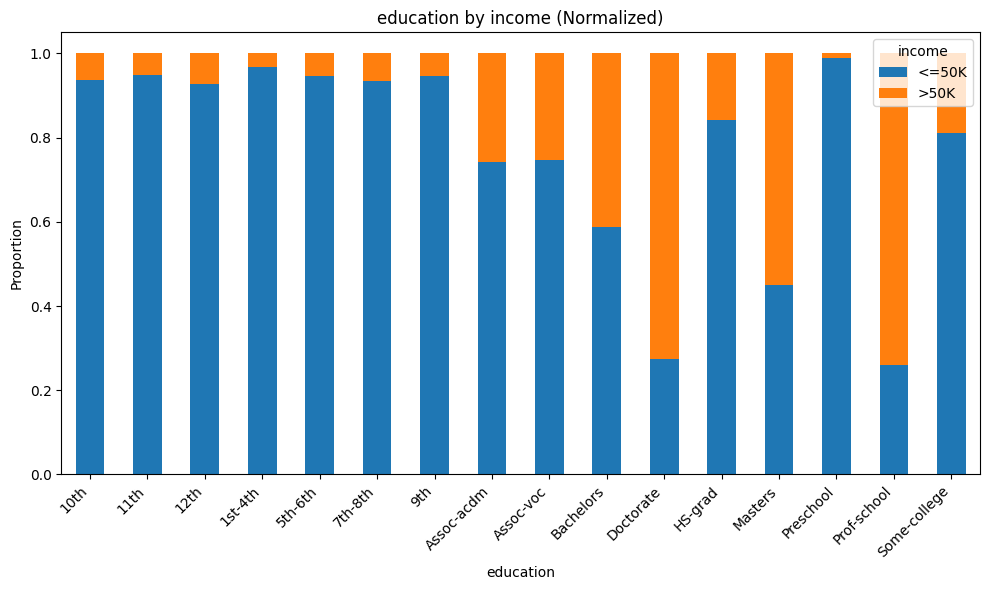

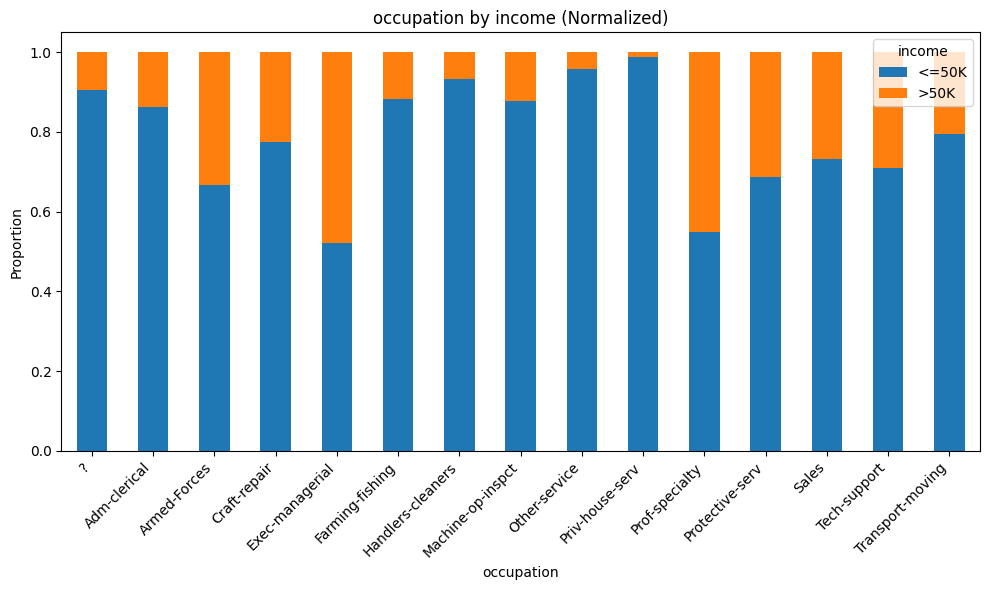

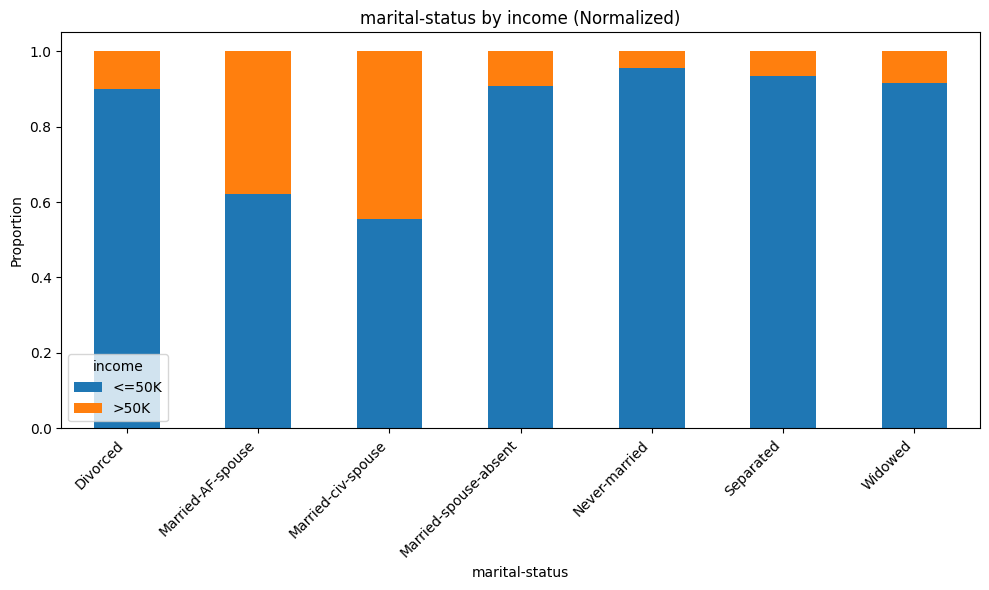

In [5]:
# Phân tích nhanh một số biến phân loại tiêu biểu
top_cat = ['education', 'occupation', 'marital-status']
eda.plot_categorical_by_target(df, top_cat, target_col='income')

<!-- @format -->

**Nhận xét:** Một số biến phân loại như education, occupation, marital-status có sự khác biệt rõ rệt giữa hai nhóm thu nhập.


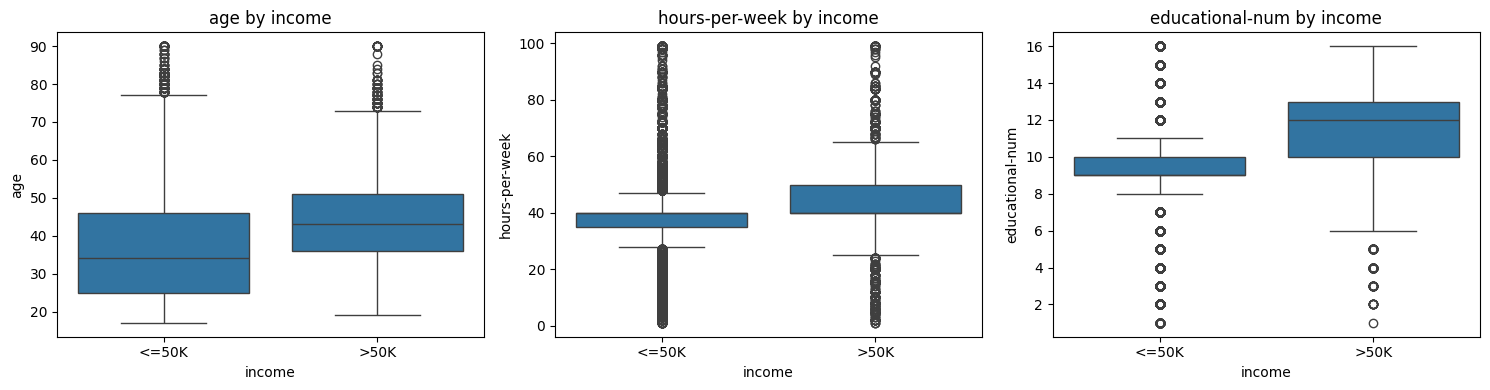

In [6]:
# Phân tích nhanh các biến số quan trọng
num_cols_sel = ['age', 'hours-per-week', 'educational-num']
eda.plot_numerical_by_target(df, num_cols_sel, target_col='income')


<!-- @format -->

**Nhận xét:** Các biến số như age, hours-per-week, educational-num đều có sự khác biệt phân phối giữa hai nhóm thu nhập.


=== capital-gain ===
count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

Zero values : 44807 (91.74%)
Non-zero    : 4035 (8.26%)

Proportion of non-zero capital-gain by income:
capital-gain  False  True 
income                    
<=50K         0.958  0.042
>50K          0.787  0.213


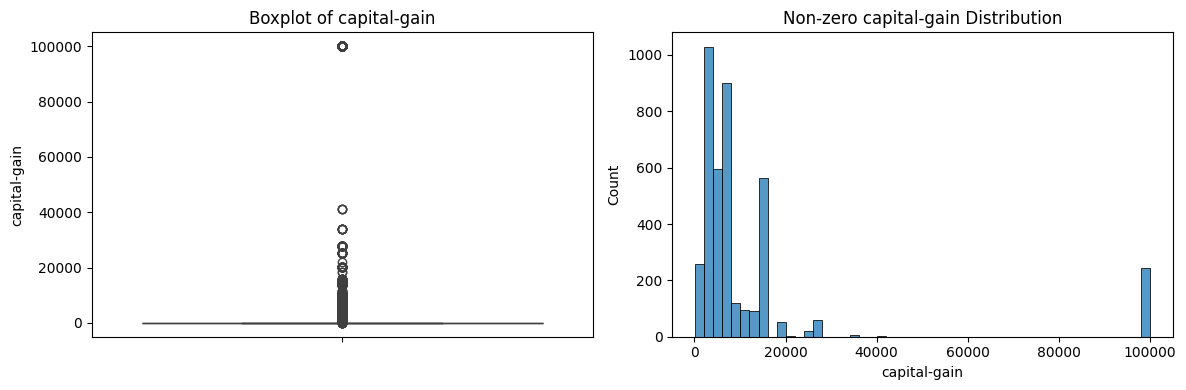

=== capital-loss ===
count    48842.000000
mean        87.502314
std        403.004552
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64

Zero values : 46560 (95.33%)
Non-zero    : 2282 (4.67%)

Proportion of non-zero capital-loss by income:
capital-loss  False  True 
income                    
<=50K         0.969  0.031
>50K          0.902  0.098


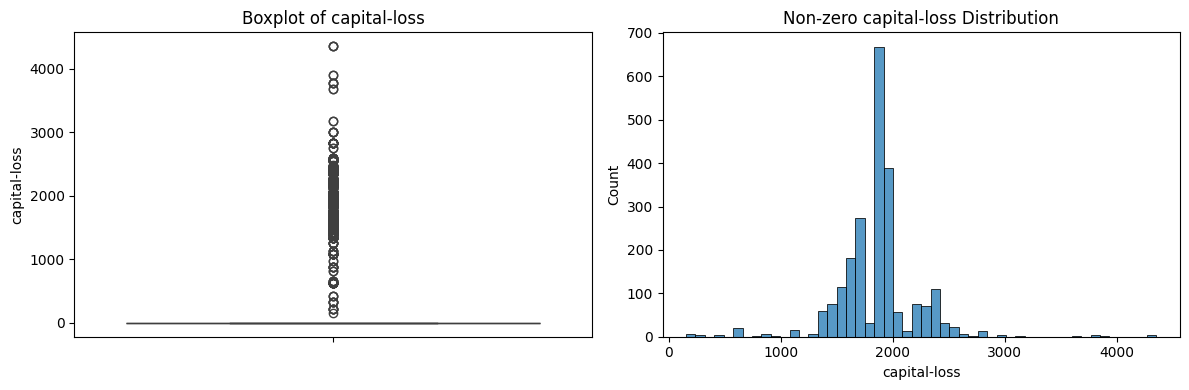

In [7]:
# Phân tích phân phối và ý nghĩa của capital-gain, capital-loss
eda.analyze_capital_feature(df, 'capital-gain', target_col='income')
eda.analyze_capital_feature(df, 'capital-loss', target_col='income')


<!-- @format -->

**Nhận xét:** Cả hai biến capital-gain và capital-loss đều có phân phối rất lệch, nhiều giá trị 0, nhưng tỷ lệ giá trị khác 0 ở nhóm >50K cao hơn đáng kể. Đây là đặc trưng hữu ích cho mô hình.


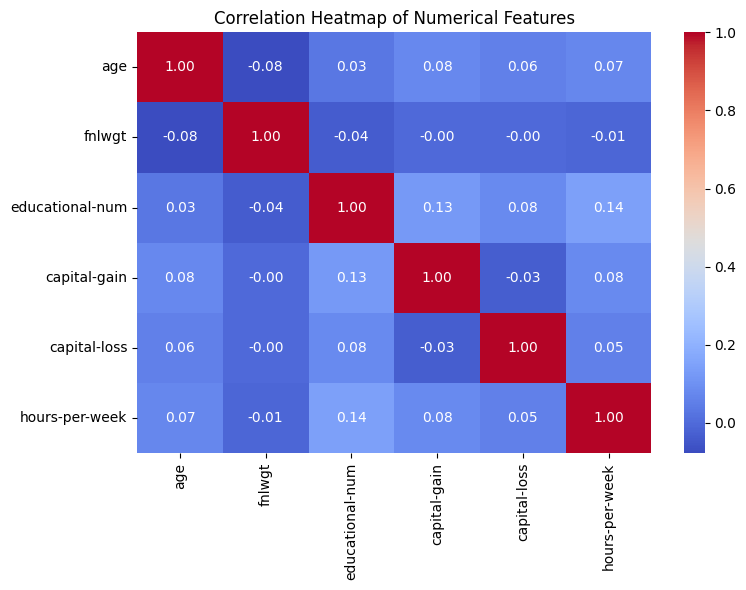

In [8]:
# Heatmap tương quan các biến số
eda.plot_correlation_heatmap(df, num_cols)


<!-- @format -->

**Nhận xét:** Các biến số không có cặp nào tương quan quá cao, có thể giữ lại hầu hết cho mô hình.


In [9]:
# Kiểm tra trùng lặp thông tin education & educational-num
eda.check_education_redundancy(df)

Mapping between education and educational-num:
       education educational-num
0           10th             [6]
1           11th             [7]
2           12th             [8]
3        1st-4th             [2]
4        5th-6th             [3]
5        7th-8th             [4]
6            9th             [5]
7     Assoc-acdm            [12]
8      Assoc-voc            [11]
9      Bachelors            [13]
10     Doctorate            [16]
11       HS-grad             [9]
12       Masters            [14]
13     Preschool             [1]
14   Prof-school            [15]
15  Some-college            [10]


<!-- @format -->

**Nhận xét:** Hai cột education và educational-num gần như mang cùng thông tin, có thể cân nhắc chỉ giữ lại một trong hai khi xây dựng mô hình.


<!-- @format -->

# 2. Tiền xử lí dữ liệu


<!-- @format -->
## 2.1. Import preprocessing module

In [10]:
import importlib
import modules.preprocessing as prep_module
importlib.reload(prep_module)

from modules.preprocessing import (
    drop_columns,
    drop_missing_values,
    map_target_variable,
    apply_ohe,
    scale_numeric,
    split_data,
    apply_smote,
)

<!-- @format -->
## 2.2. Làm sạch dữ liệu

Các bước:
1. **Xoá cột dư thừa**: `education` (trùng thông tin với `educational-num`) và `fnlwgt` (trọng số thống kê, không liên quan phân loại).
2. **Xử lý giá trị `?`**: thay bằng `NaN` rồi xoá các hàng thiếu.
3. **Mã hoá biến mục tiêu**: `<=50K` → 0, `>50K` → 1.

In [11]:
df_clean = df.copy()

# 1. Xoá cột dư thừa
df_clean = drop_columns(df_clean, columns=['education', 'fnlwgt'])

# 2. Xử lý missing value ('?' → NaN → drop row)
df_clean = drop_missing_values(df_clean)

# 3. Mã hoá biến mục tiêu
df_clean = map_target_variable(df_clean, target_col='income')

print(f"\nKích thước sau làm sạch: {df_clean.shape}")
df_clean.head()

Dropped columns: ['education', 'fnlwgt']
Dropped rows with missing values: 3620
Mapped target variable 'income' to binary.

Kích thước sau làm sạch: (45222, 13)


,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
5,34,Private,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0


<!-- @format -->
## 2.3. Xác định loại đặc trưng

In [12]:
TARGET_COL = 'income'

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

# Bỏ target khỏi danh sách (nếu có)
if TARGET_COL in num_cols: num_cols.remove(TARGET_COL)
if TARGET_COL in cat_cols: cat_cols.remove(TARGET_COL)

print(f"Numerical features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Numerical features (5): ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features (7): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


<!-- @format -->
## 2.4. Chia dữ liệu Train / Val / Test

Split **trước** khi encode & scale để tránh data leakage.
Tỉ lệ: **70% train – 10% val – 20% test** (stratify theo `income`).

In [13]:
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = split_data(
    df_clean,
    target_col=TARGET_COL,
    test_size=0.2,
    val_size=0.1,
    random_state=42,
)

Split data → Train: 31654, Val: 4523, Test: 9045
  Class dist (train) >50K: 24.8%


<!-- @format -->
## 2.5. One-Hot Encoding (categorical)

Fit `OneHotEncoder` **chỉ trên train**, sau đó transform val/test bằng cùng encoder đó.

In [14]:
X_train_ohe, ohe_encoder = apply_ohe(X_train_raw, cat_cols)
X_val_ohe, _= apply_ohe(X_val_raw,   cat_cols, encoder=ohe_encoder)
X_test_ohe, _= apply_ohe(X_test_raw,  cat_cols, encoder=ohe_encoder)

print(f"\nShape sau OHE  →  train: {X_train_ohe.shape} | val: {X_val_ohe.shape} | test: {X_test_ohe.shape}")

Applied OHE on 7 columns, resulted in 82 new columns.
Applied OHE on 7 columns, resulted in 82 new columns.
Applied OHE on 7 columns, resulted in 82 new columns.

Shape sau OHE  →  train: (31654, 87) | val: (4523, 87) | test: (9045, 87)


<!-- @format -->
## 2.6. Chuẩn hoá đặc trưng số (StandardScaler)

Fit `StandardScaler` **chỉ trên train**, transform val/test.

In [15]:
X_train_sc, scaler = scale_numeric(X_train_ohe, num_cols)
X_val_sc,   _      = scale_numeric(X_val_ohe,   num_cols, scaler=scaler)
X_test_sc,  _      = scale_numeric(X_test_ohe,  num_cols, scaler=scaler)

Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Scaled 5 numeric columns: ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


<!-- @format -->
## 2.7. Cân bằng lớp bằng SMOTE

Dữ liệu có **mất cân bằng ~24%** ở lớp `>50K`.
SMOTE sinh các mẫu tổng hợp cho lớp thiểu số **chỉ trên tập train** để tránh data leakage.

> **Lưu ý**: SMOTE phải được gọi **sau khi encode & scale** (vì cần tính khoảng cách Euclidean trên không gian số).
> Val/test **không được** áp dụng SMOTE – phải giữ nguyên phân phối thực tế.

In [16]:
X_train_sm, y_train_sm = apply_smote(
    X_train_sc,
    y_train,
    sampling_strategy='auto',   # cân bằng 50/50
    k_neighbors=5,
    random_state=42,
)

SMOTE applied (strategy='auto', k=5)
  Before → {0: 23809, 1: 7845}  |  total=31654
  After  → {0: 23809, 1: 23809}   |  total=47618
  Class dist after SMOTE >50K: 50.0%


<!-- @format -->
## 2.8. Tóm tắt kết quả preprocessing

In [17]:
import pandas as pd

summary = pd.DataFrame({
    'Split':      ['Train (sau SMOTE)', 'Val (giữ nguyên)', 'Test (giữ nguyên)'],
    'Samples':    [len(X_train_sm), len(X_val_sc), len(X_test_sc)],
    'Features':   [X_train_sm.shape[1], X_val_sc.shape[1], X_test_sc.shape[1]],
    'Class >50K': [
        f"{y_train_sm.mean():.1%}",
        f"{y_val.mean():.1%}",
        f"{y_test.mean():.1%}",
    ],
})
print(summary.to_string(index=False))
print(f"\nEncoding artifacts saved:")
print(f"  ohe_encoder : {type(ohe_encoder).__name__}")
print(f"  scaler      : {type(scaler).__name__}")

            Split  Samples  Features Class >50K
Train (sau SMOTE)    47618        87      50.0%
 Val (giữ nguyên)     4523        87      24.8%
Test (giữ nguyên)     9045        87      24.8%

Encoding artifacts saved:
  ohe_encoder : OneHotEncoder
  scaler      : StandardScaler


<!-- @format -->
# 3. Logistic Regression (Baseline)

Logistic Regression được dùng làm **baseline** để so sánh với MLP sau này.

**Lý do chọn làm baseline:**
- Đơn giản, huấn luyện nhanh, dễ giải thích
- Hiệu quả tốt với dữ liệu đã được scale và OHE
- Kết quả của nó là ngưỡng tối thiểu mà MLP cần vượt qua

<!-- @format -->
## 3.1. Huấn luyện Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
)
import matplotlib.pyplot as plt
import numpy as np

# Dùng X_train_sm (sau SMOTE) để train
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
)
lr_model.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained.")

Logistic Regression trained.


<!-- @format -->
## 3.2. Đánh giá trên Val set

In [19]:
y_val_pred_lr  = lr_model.predict(X_val_sc)
y_val_proba_lr = lr_model.predict_proba(X_val_sc)[:, 1]

print("=== Logistic Regression – Val Set ===")
print(classification_report(y_val, y_val_pred_lr, target_names=['<=50K', '>50K']))

val_metrics_lr = {
    'accuracy' : round(accuracy_score(y_val,  y_val_pred_lr),  4),
    'precision': round(precision_score(y_val, y_val_pred_lr),  4),
    'recall'   : round(recall_score(y_val,    y_val_pred_lr),  4),
    'f1'       : round(f1_score(y_val,        y_val_pred_lr),  4),
    'roc_auc'  : round(roc_auc_score(y_val,   y_val_proba_lr), 4),
}
print("Val metrics:", val_metrics_lr)

=== Logistic Regression – Val Set ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      3402
        >50K       0.57      0.85      0.68      1121

    accuracy                           0.80      4523
   macro avg       0.76      0.82      0.77      4523
weighted avg       0.85      0.80      0.81      4523

Val metrics: {'accuracy': 0.8041, 'precision': 0.5704, 'recall': 0.8492, 'f1': 0.6824, 'roc_auc': 0.9056}


<!-- @format -->
## 3.3. Đánh giá trên Test set

=== Logistic Regression – Test Set ===
              precision    recall  f1-score   support

       <=50K       0.94      0.79      0.86      6803
        >50K       0.57      0.84      0.68      2242

    accuracy                           0.80      9045
   macro avg       0.76      0.82      0.77      9045
weighted avg       0.85      0.80      0.82      9045

Test metrics: {'accuracy': 0.8048, 'precision': 0.5719, 'recall': 0.8443, 'f1': 0.6819, 'roc_auc': 0.9038}


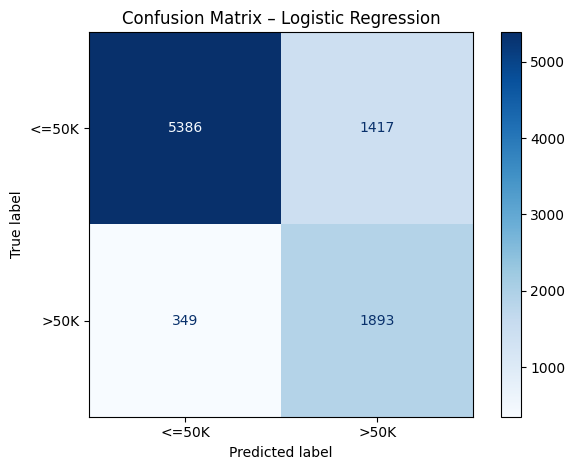

In [20]:
y_test_pred_lr  = lr_model.predict(X_test_sc)
y_test_proba_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression – Test Set ===")
print(classification_report(y_test, y_test_pred_lr, target_names=['<=50K', '>50K']))

test_metrics_lr = {
    'accuracy' : round(accuracy_score(y_test,  y_test_pred_lr),  4),
    'precision': round(precision_score(y_test, y_test_pred_lr),  4),
    'recall'   : round(recall_score(y_test,    y_test_pred_lr),  4),
    'f1'       : round(f1_score(y_test,        y_test_pred_lr),  4),
    'roc_auc'  : round(roc_auc_score(y_test,   y_test_proba_lr), 4),
}
print("Test metrics:", test_metrics_lr)

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
disp  = ConfusionMatrixDisplay(cm_lr, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Logistic Regression')
plt.tight_layout()
plt.show()

<!-- @format -->
# 4. MLP – Multi-Layer Perceptron

So sánh MLP với Logistic Regression baseline.

**Kiến trúc MLP:**
- Input layer → Hidden layers (BatchNorm → ReLU → Dropout) → Output (1 logit)
- Loss: `BCEWithLogitsLoss` với `pos_weight` để xử lý class imbalance còn lại trên val/test
- Optimizer: Adam + ReduceLROnPlateau scheduler
- Early stopping theo `val_loss`

<!-- @format -->
## 4.1. Setup device & DataLoaders

In [21]:
import importlib
import modules.deep_learning as dl
importlib.reload(dl)

import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# Đóng gói dữ liệu đã preprocessing vào dict chuẩn của dl module
prep = {
    'X_train': X_train_sm.values.astype('float32'),
    'X_val'  : X_val_sc.values.astype('float32'),
    'X_test' : X_test_sc.values.astype('float32'),
    'y_train': y_train_sm.values.astype('int64'),
    'y_val'  : y_val.values.astype('int64'),
    'y_test' : y_test.values.astype('int64'),
    'input_dim': X_train_sm.shape[1],
}

train_loader, val_loader, test_loader = dl.create_dataloaders(prep, batch_size=256)

Using device: cpu
DataLoaders created  |  batch_size=256
  Train batches: 187  |  Val batches: 18  |  Test batches: 36


<!-- @format -->
## 4.2. MLP cơ bản [256, 128, 64]

In [ ]:
model_mlp = dl.MLP(
    input_dim=prep['input_dim'],
    hidden_dims=[256, 128, 64],
    dropout=0.4,
)
print(model_mlp)
print(f"Tổng số tham số: {sum(p.numel() for p in model_mlp.parameters()):,}")

MLP(
  (net): Sequential(
    (linear_0): Linear(in_features=87, out_features=256, bias=True)
    (bn_0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_0): ReLU()
    (drop_0): Dropout(p=0.5, inplace=False)
    (linear_1): Linear(in_features=256, out_features=128, bias=True)
    (bn_1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_1): ReLU()
    (drop_1): Dropout(p=0.5, inplace=False)
    (linear_2): Linear(in_features=128, out_features=64, bias=True)
    (bn_2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_2): ReLU()
    (drop_2): Dropout(p=0.5, inplace=False)
    (output): Linear(in_features=64, out_features=1, bias=True)
  )
)
Tổng số tham số: 64,641


In [ ]:
history_mlp = dl.train_model(
    model_mlp,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-3,
    patience=15,
    device=device,
    use_pos_weight=False,
)

use_pos_weight=False: BCEWithLogitsLoss không trọng số (train data đã cân bằng bằng SMOTE).
Training on cpu  |  epochs=100  |  lr=0.001  |  patience=15
----------------------------------------------------------------------
Epoch   1/100  |  train_loss=0.4202  train_acc=0.8057  |  val_loss=0.3885  val_acc=0.8041 *
Epoch   2/100  |  train_loss=0.3824  train_acc=0.8263  |  val_loss=0.3818  val_acc=0.8094 *
Epoch   3/100  |  train_loss=0.3772  train_acc=0.8297  |  val_loss=0.3554  val_acc=0.8262 *
Epoch   5/100  |  train_loss=0.3714  train_acc=0.8312  |  val_loss=0.3918  val_acc=0.8125
Epoch   9/100  |  train_loss=0.3687  train_acc=0.8322  |  val_loss=0.3546  val_acc=0.8222 *
Epoch  10/100  |  train_loss=0.3674  train_acc=0.8333  |  val_loss=0.3655  val_acc=0.8156
Epoch  15/100  |  train_loss=0.3638  train_acc=0.8347  |  val_loss=0.3745  val_acc=0.8110
Epoch  20/100  |  train_loss=0.3523  train_acc=0.8403  |  val_loss=0.3983  val_acc=0.7933

Early stopping at epoch 24 (best val_loss=0.3546

<!-- @format -->
## 4.3. Learning Curves

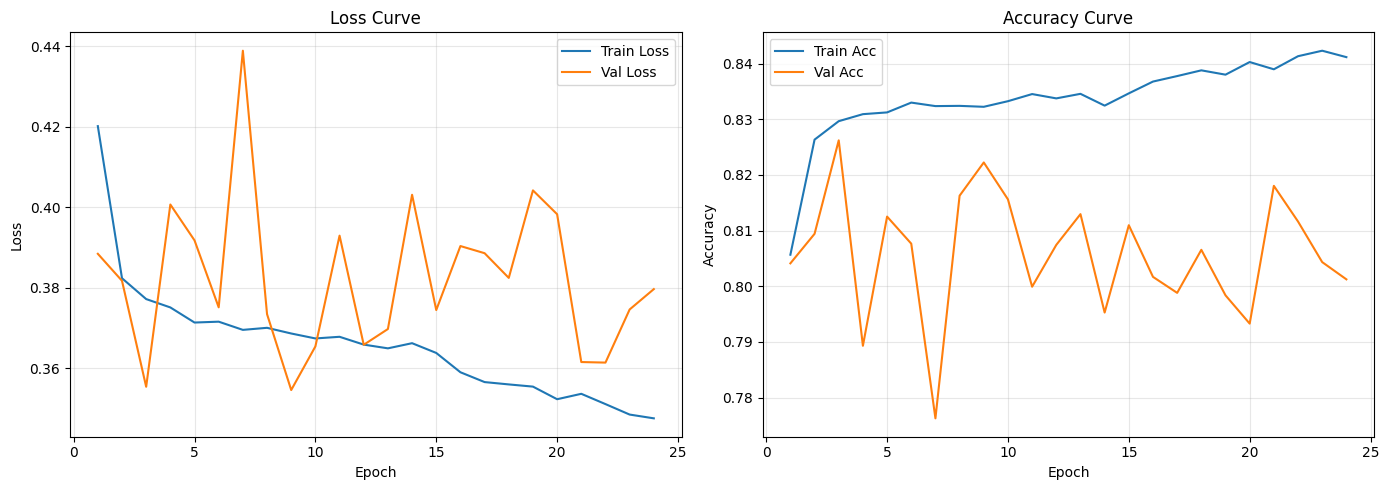

In [30]:
dl.plot_learning_curves(history_mlp)

<!-- @format -->
## 4.4. Đánh giá MLP trên Test set

=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.95      0.78      0.85      6803
        >50K       0.56      0.87      0.68      2242

    accuracy                           0.80      9045
   macro avg       0.75      0.82      0.77      9045
weighted avg       0.85      0.80      0.81      9045

Summary: {'accuracy': 0.7992, 'precision': 0.5616, 'recall': 0.8662, 'f1_score': 0.6814}


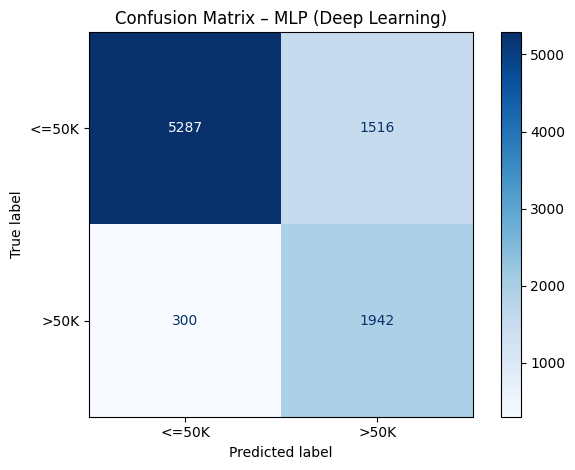

In [31]:
test_metrics_mlp, y_true_mlp, y_pred_mlp, y_proba_mlp = dl.evaluate_model(
    model_mlp, test_loader, device=device
)

<!-- @format -->
## 4.5. So sánh Logistic Regression vs MLP

In [32]:
import pandas as pd

compare = pd.DataFrame([
    {
        'Model'    : 'Logistic Regression (baseline)',
        'Accuracy' : test_metrics_lr['accuracy'],
        'Precision': test_metrics_lr['precision'],
        'Recall'   : test_metrics_lr['recall'],
        'F1-Score' : test_metrics_lr['f1'],
        'ROC-AUC'  : test_metrics_lr['roc_auc'],
    },
    {
        'Model'    : 'MLP [256, 128, 64]',
        'Accuracy' : test_metrics_mlp['accuracy'],
        'Precision': test_metrics_mlp['precision'],
        'Recall'   : test_metrics_mlp['recall'],
        'F1-Score' : test_metrics_mlp['f1_score'],
        'ROC-AUC'  : round(roc_auc_score(y_true_mlp, y_proba_mlp), 4),
    },
])

compare = compare.set_index('Model')
print(compare.to_string())
compare.style.highlight_max(axis=0, color='lightgreen')

                                Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                         
Logistic Regression (baseline)    0.8048     0.5719  0.8443    0.6819   0.9038
MLP [256, 128, 64]                0.7992     0.5616  0.8662    0.6814   0.9074


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (baseline),0.804800,0.571900,0.844300,0.681900,0.903800
"MLP [256, 128, 64]",0.799200,0.561600,0.866200,0.681400,0.907400


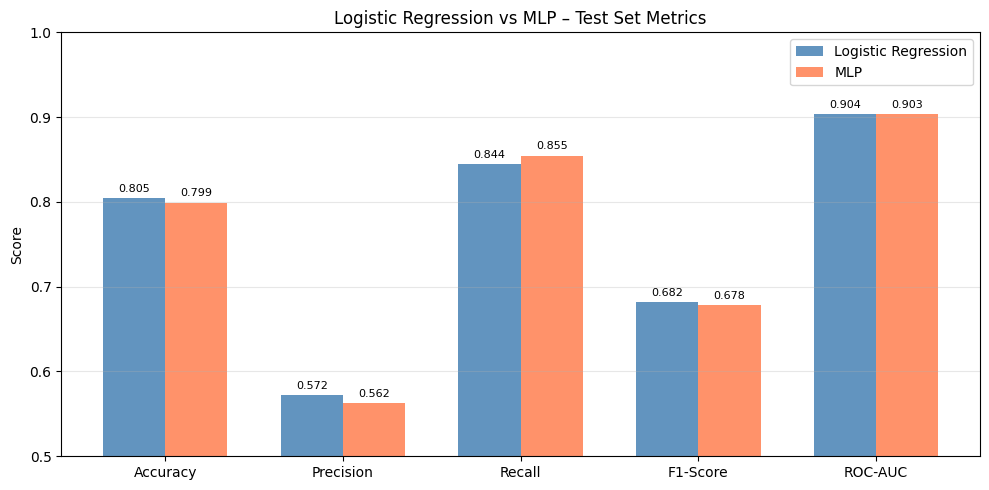

In [27]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare.loc['Logistic Regression (baseline)', metrics_to_plot],
               width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, compare.loc['MLP [256, 128, 64]', metrics_to_plot],
               width, label='MLP', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs MLP – Test Set Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()